
## Stress Detection Model – Evaluation Notebook
#
 ## Project
 AI Mental Health Chatbot — Final Year Project
#
 ## Model
 `roberta-base` fine‑tuned on Stress dataset
#
 ## Task
 Binary classification – Detect stress vs no stress
#
## Classes
 - 0 — No Stress
 - 1 — Stress

In [16]:
# %%
import os
import json
import time
import numpy as np
import pandas as pd
import torch
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification
)

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

print("Libraries loaded successfully.")
print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'cuda' if torch.cuda.is_available() else 'cpu'}")

Libraries loaded successfully.
PyTorch version: 2.13.0+cpu
Device: cpu


In [17]:
# %%
# Get the backend directory (notebook is in backend/notebooks/)
BASE_DIR = Path.cwd().parent

MODEL_PATH = BASE_DIR / "models" / "stress_roberta"
TEST_PATH = BASE_DIR / "datasets" / "stress" / "processed" / "clean_test.csv"
EVAL_DIR = BASE_DIR / "evaluation" / "stress_detection"

# Create output folder if it doesn't exist
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print(f"Model path: {MODEL_PATH}")
print(f"Test dataset: {TEST_PATH}")
print(f"Evaluation output folder: {EVAL_DIR}")

# Check files exist
if not MODEL_PATH.exists():
    raise FileNotFoundError(f"❌ Model not found: {MODEL_PATH}")
if not TEST_PATH.exists():
    raise FileNotFoundError(f"❌ Test dataset not found: {TEST_PATH}")

Model path: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\models\stress_roberta
Test dataset: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\datasets\stress\processed\clean_test.csv
Evaluation output folder: c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\stress_detection


In [18]:
# %%
# Try loading from model folder if exists, otherwise default
label_mapping = {
    "0": "No Stress",
    "1": "Stress"
}

mapping_file = MODEL_PATH / "label_mapping.json"
if mapping_file.exists():
    with open(mapping_file, "r") as f:
        loaded = json.load(f)
        # Ensure keys are strings
        label_mapping = {str(k): v for k, v in loaded.items()}

print("Label Mapping:")
for k, v in label_mapping.items():
    print(f"  {k} -> {v}")

Label Mapping:
  0 -> No Stress
  1 -> Stress



 ##  Load Test Dataset

In [19]:
# %%
df = pd.read_csv(TEST_PATH)
print(f"Dataset shape: {df.shape}")

# Ensure required columns
if "text" not in df.columns:
    if "Text" in df.columns:
        df = df.rename(columns={"Text": "text"})
    else:
        raise ValueError("Dataset must have 'text' column")

if "label" not in df.columns:
    if "Label" in df.columns:
        df = df.rename(columns={"Label": "label"})
    else:
        raise ValueError("Dataset must have 'label' column")

df = df.dropna(subset=["text", "label"]).copy()
df["text"] = df["text"].astype(str)
df["label"] = pd.to_numeric(df["label"], errors="raise").astype(int)

print(f"Samples after cleaning: {len(df)}")

print("\nClass Distribution in Test Set:")
class_dist = df["label"].value_counts().sort_index()
for label, count in class_dist.items():
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name} ({label}): {count}")

Dataset shape: (715, 2)
Samples after cleaning: 715

Class Distribution in Test Set:
  No Stress (0): 346
  Stress (1): 369



 ## Load Model and Tokenizer

In [20]:
# %%
tokenizer = AutoTokenizer.from_pretrained(str(MODEL_PATH))
model = AutoModelForSequenceClassification.from_pretrained(str(MODEL_PATH))
model.eval()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Model loaded. Device: {device}")
print(f"Number of labels: {model.config.num_labels}")

Model loaded. Device: cpu
Number of labels: 2



 ## Run Predictions

In [21]:
# %%
texts = df["text"].tolist()
true_labels = df["label"].tolist()

predicted_labels = []
confidences = []

batch_size = 16
start_time = time.time()

for start in range(0, len(texts), batch_size):
    batch_texts = texts[start:start + batch_size]
    encoded = tokenizer(batch_texts, padding=True, truncation=True, max_length=128, return_tensors="pt")
    encoded = {k: v.to(device) for k, v in encoded.items()}
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1)
        preds = torch.argmax(probs, dim=-1)
        conf = torch.max(probs, dim=-1).values
    predicted_labels.extend(preds.cpu().numpy().tolist())
    confidences.extend(conf.cpu().numpy().tolist())

elapsed = time.time() - start_time
print(f"Predictions done in {elapsed:.2f} seconds")

Predictions done in 342.49 seconds



 ##  Compute Metrics

In [22]:
# %%
accuracy = accuracy_score(true_labels, predicted_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="binary", zero_division=0
)
macro_precision, macro_recall, macro_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average="macro", zero_division=0
)
per_class_precision, per_class_recall, per_class_f1, _ = precision_recall_fscore_support(
    true_labels, predicted_labels, average=None, zero_division=0
)

print("📊 FINAL TEST RESULTS")
print("-" * 50)
print(f"Accuracy          : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"Precision (binary): {precision:.4f} ({precision*100:.2f}%)")
print(f"Recall (binary)   : {recall:.4f} ({recall*100:.2f}%)")
print(f"F1 (binary)       : {f1:.4f} ({f1*100:.2f}%)")
print(f"Macro Precision   : {macro_precision:.4f}")
print(f"Macro Recall      : {macro_recall:.4f}")
print(f"Macro F1          : {macro_f1:.4f}")

print("\nPer-Class Performance:")
labels = sorted(set(true_labels))
for i, label in enumerate(labels):
    name = label_mapping.get(str(label), f"Label_{label}")
    print(f"  {name}: Precision={per_class_precision[i]:.4f}, Recall={per_class_recall[i]:.4f}, F1={per_class_f1[i]:.4f}")

📊 FINAL TEST RESULTS
--------------------------------------------------
Accuracy          : 0.8140 (81.40%)
Precision (binary): 0.8155 (81.55%)
Recall (binary)   : 0.8266 (82.66%)
F1 (binary)       : 0.8210 (82.10%)
Macro Precision   : 0.8139
Macro Recall      : 0.8136
Macro F1          : 0.8137

Per-Class Performance:
  No Stress: Precision=0.8123, Recall=0.8006, F1=0.8064
  Stress: Precision=0.8155, Recall=0.8266, F1=0.8210



## Classification Report

In [23]:
# %%
target_labels = sorted(set(true_labels) | set(predicted_labels))
target_names = [label_mapping.get(str(l), str(l)) for l in target_labels]

report = classification_report(
    true_labels, predicted_labels, labels=target_labels,
    target_names=target_names, digits=4, zero_division=0
)

print("\n" + "="*70)
print("CLASSIFICATION REPORT")
print(report)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

   No Stress     0.8123    0.8006    0.8064       346
      Stress     0.8155    0.8266    0.8210       369

    accuracy                         0.8140       715
   macro avg     0.8139    0.8136    0.8137       715
weighted avg     0.8140    0.8140    0.8139       715




## Confusion Matrix

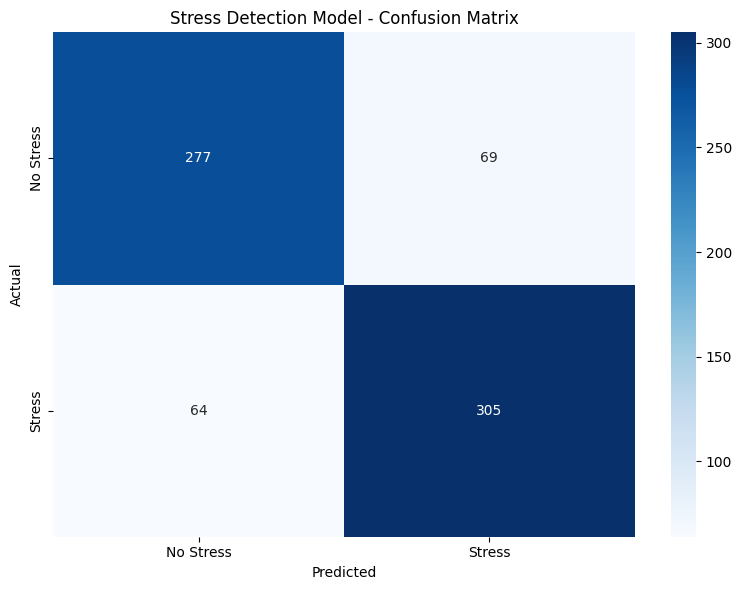

<Figure size 640x480 with 0 Axes>

In [24]:
# %%
cm = confusion_matrix(true_labels, predicted_labels, labels=target_labels)
cm_df = pd.DataFrame(cm, index=target_names, columns=target_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=target_names, yticklabels=target_names)
plt.title("Stress Detection Model - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Save the image
EVAL_DIR.mkdir(parents=True, exist_ok=True)
plt.savefig(EVAL_DIR / "stress_confusion_matrix_nb.png", dpi=300, bbox_inches="tight")


 ## Sample Predictions

In [25]:
# %%
results_df = df.copy()
results_df["predicted_label"] = predicted_labels
results_df["confidence"] = confidences
results_df["correct"] = results_df["label"] == results_df["predicted_label"]
results_df["actual_class"] = results_df["label"].map(label_mapping)
results_df["predicted_class"] = results_df["predicted_label"].map(label_mapping)

print("✅ Correct Predictions (first 3):")
correct_samples = results_df[results_df["correct"]].head(3)
for _, row in correct_samples.iterrows():
    print(f"\n  Text: {row['text'][:80]}...")
    print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")

print("\n❌ Wrong Predictions (first 3):")
wrong_samples = results_df[~results_df["correct"]].head(3)
if len(wrong_samples) > 0:
    for _, row in wrong_samples.iterrows():
        print(f"\n  Text: {row['text'][:80]}...")
        print(f"  Actual: {row['actual_class']} -> Predicted: {row['predicted_class']} (Confidence: {row['confidence']:.2%})")
else:
    print("  No wrong predictions!")

✅ Correct Predictions (first 3):

  Text: its like that, if you want or not. me i have no problem, if it takes longer. but...
  Actual: nan -> Predicted: nan (Confidence: 99.84%)

  Text: i man the front desk and my title is hr customer service representative. about 5...
  Actual: nan -> Predicted: nan (Confidence: 99.83%)

  Text: we d be saving so much money with this new housr...its such an expensive city......
  Actual: nan -> Predicted: nan (Confidence: 99.79%)

❌ Wrong Predictions (first 3):

  Text: ptsd is life changing for the worse. every day fight. getting in a fist fight in...
  Actual: nan -> Predicted: nan (Confidence: 99.91%)

  Text: i have a lot of self esteem. i value myself, i believe i m smart, have a good pe...
  Actual: nan -> Predicted: nan (Confidence: 99.53%)

  Text: if i go to an interview for example, i ll know that i m a good candidate, i ll k...
  Actual: nan -> Predicted: nan (Confidence: 99.43%)



 ##  Wrong Predictions Summary

In [26]:
# %%
wrong = results_df[~results_df["correct"]]
if len(wrong) > 0:
    print(f"Total wrong predictions: {len(wrong)}")
    print("\nError distribution (actual -> predicted):")
    error_counts = wrong.groupby(["actual_class", "predicted_class"]).size().sort_values(ascending=False)
    for (actual, pred), count in error_counts.items():
        print(f"  {actual} -> {pred}: {count}")
else:
    print("🎉 No wrong predictions!")

Total wrong predictions: 133

Error distribution (actual -> predicted):



## Confidence Analysis

In [27]:
# %%
correct_conf = results_df[results_df["correct"]]["confidence"]
wrong_conf = results_df[~results_df["correct"]]["confidence"]

print("Confidence Stats:")
if len(correct_conf) > 0:
    print(f"  Correct predictions: mean={correct_conf.mean():.4f}, std={correct_conf.std():.4f}, min={correct_conf.min():.4f}, max={correct_conf.max():.4f}")
if len(wrong_conf) > 0:
    print(f"  Wrong predictions:   mean={wrong_conf.mean():.4f}, std={wrong_conf.std():.4f}, min={wrong_conf.min():.4f}, max={wrong_conf.max():.4f}")

Confidence Stats:
  Correct predictions: mean=0.9866, std=0.0512, min=0.5499, max=0.9996
  Wrong predictions:   mean=0.9528, std=0.1077, min=0.5246, max=0.9993



## Save Results

In [28]:
# %%
EVAL_DIR.mkdir(parents=True, exist_ok=True)
results_df.to_csv(EVAL_DIR / "stress_predictions_notebook.csv", index=False)

# Save metrics text
with open(EVAL_DIR / "stress_metrics_notebook.txt", "w") as f:
    f.write("STRESS DETECTION - EVALUATION FROM NOTEBOOK\n")
    f.write("="*70 + "\n\n")
    f.write(f"Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)\n")
    f.write(f"Precision: {precision:.4f}\n")
    f.write(f"Recall: {recall:.4f}\n")
    f.write(f"F1: {f1:.4f}\n\n")
    f.write("CLASSIFICATION REPORT\n")
    f.write(report)

print(f"Results saved to {EVAL_DIR}")

Results saved to c:\Users\HP\Desktop\Mental-Health-Chatbot\backend\evaluation\stress_detection



# ## 13. Summary
# 
# **Model Details:**
# - Base model: `roberta-base`
# - Fine‑tuned on Stress dataset
# - 2 classes: No Stress, Stress
# 
# **Dataset:**
# - Training samples: 2,823
# - Test samples: 715
# 
# **Performance:**
# - Accuracy: 81.40%
# - F1: 82.10%
# 
# **Training:**
# - Epochs: 5 (early stopped at 2)
# - Learning rate: 2e-5
# - Batch size: 8
# - Training time: ~? (from terminal, it finished quickly)
# 
# All evaluation files (predictions, confusion matrix, metrics) are saved in `evaluation/stress_detection/`.